# PLKSR-Rep 前向推理 Demo

本 Notebook 使用项目正式推理代码加载模型，对 Set5 的 5 张 Bicubic ×4 LR 图片执行批量前向推理，并展示、汇总和保存结果。

> 运行前请使用 `msr` Conda 环境，并确认官方权重位于 `model_zoo/19_PLKSRRep_IQAv2Short/net_g_1000.pth`。

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys
import time

import numpy as np

ENV_NAME = Path(sys.executable).parent.parent.name
if ENV_NAME != 'msr':
    raise RuntimeError(
        f'当前内核不是 msr（Python: {sys.executable}）。'
        '请切换到 Python (msr)，然后重启内核并重新运行全部单元。'
    )
if int(np.__version__.split('.')[0]) >= 2:
    raise RuntimeError(
        f'当前 NumPy {np.__version__} 与 PyTorch 2.1.0 不兼容；'
        '请使用已配置 NumPy 1.26.4 的 Python (msr) 内核。'
    )

import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from basicsr.utils import img2tensor, tensor2img

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'scripts' / 'inference_ntire.py').exists():
    raise RuntimeError(f'请从项目根目录启动 Notebook，当前目录：{PROJECT_ROOT}')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.inference_ntire import load_model, set_determinism

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WEIGHTS = PROJECT_ROOT / 'model_zoo/19_PLKSRRep_IQAv2Short/net_g_1000.pth'
INPUT_DIR = PROJECT_ROOT / 'testsets/Set5_LR_x4'
OUTPUT_DIR = PROJECT_ROOT / 'tmp/notebook_demo/set5_sr_x4'
PREPAD = 16
USE_FP16 = False  # 官方最终结果使用 FP32

print(f'Python: {sys.executable}')
print(f'NumPy: {np.__version__}')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Python: /data1/yinjian/miniforge3/envs/msr/bin/python
NumPy: 1.26.4
PyTorch: 2.1.0
Device: cuda
GPU: NVIDIA GeForce RTX 4090


/data1/yinjian/miniforge3/envs/msr/lib/python3.10/site-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


## 1. 准备 Set5 输入图片

读取 `testsets/Set5_LR_x4/` 中的 baby、bird、butterfly、head 和 woman，并先展示全部 LR 输入。

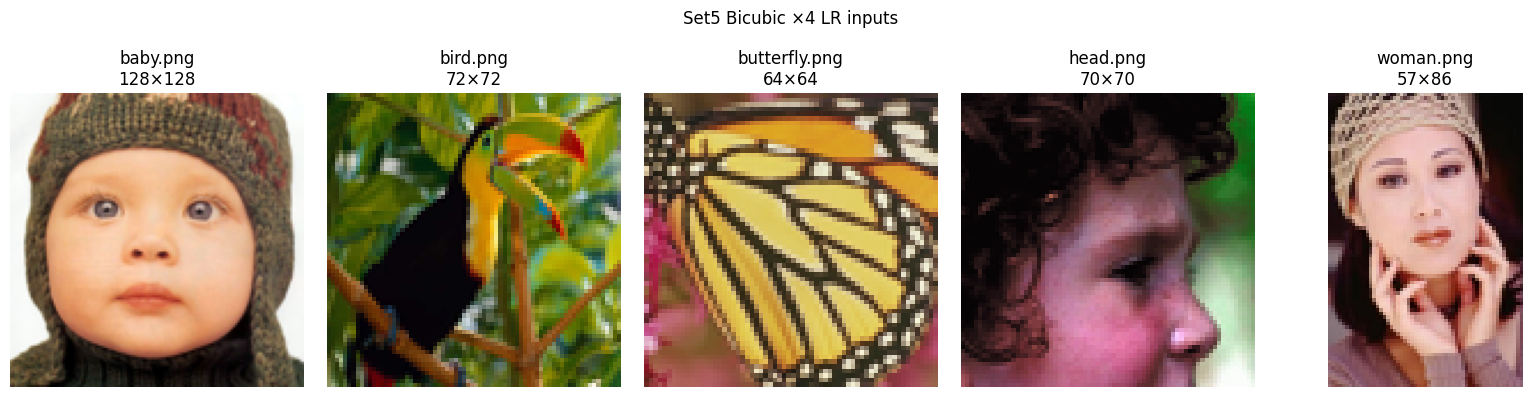

Input directory: /data1/yinjian/ntire2026-mobile-realworld-sr-vipsl19/testsets/Set5_LR_x4
Image count: 5


In [2]:
image_paths = sorted(INPUT_DIR.glob('*.png'))
if not image_paths:
    raise FileNotFoundError(f'目录中没有 PNG 测试图片：{INPUT_DIR}')

inputs = {}
for path in image_paths:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise RuntimeError(f'无法读取图片：{path}')
    inputs[path.name] = image_bgr

fig, axes = plt.subplots(1, len(inputs), figsize=(16, 4))
for axis, (name, image_bgr) in zip(axes, inputs.items()):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    axis.imshow(image_rgb)
    axis.set_title(f'{name}\n{image_rgb.shape[1]}×{image_rgb.shape[0]}')
    axis.axis('off')
plt.suptitle('Set5 Bicubic ×4 LR inputs')
plt.tight_layout()
plt.show()
print(f'Input directory: {INPUT_DIR}')
print(f'Image count: {len(inputs)}')

## 2. 加载 PLKSR-Rep 模型

In [3]:
if not WEIGHTS.exists():
    raise FileNotFoundError(f'找不到模型权重：{WEIGHTS}')

model_args = SimpleNamespace(
    arch='plksr_rep',
    dim=64,
    n_blocks=12,
)
set_determinism(seed=0)
model = load_model(str(WEIGHTS), DEVICE, model_args)
parameter_count = sum(p.numel() for p in model.parameters())
print(f'Weights: {WEIGHTS}')
print(f'Parameters: {parameter_count / 1e6:.3f} M')

Weights: /data1/yinjian/ntire2026-mobile-realworld-sr-vipsl19/model_zoo/19_PLKSRRep_IQAv2Short/net_g_1000.pth
Parameters: 3.381 M


## 3. 前处理与前向推理

模型只加载一次。每张图片由 `img2tensor` 转换为 RGB/NCHW 张量，反射填充后执行 FP32 前向推理，再裁掉 4× 输出中的对应边界。

In [4]:
results = {}
for name, input_bgr in inputs.items():
    lq = input_bgr.astype(np.float32) / 255.0
    lq = img2tensor(lq, bgr2rgb=True, float32=True).unsqueeze(0).to(DEVICE)
    if PREPAD > 0:
        lq = F.pad(lq, (PREPAD, PREPAD, PREPAD, PREPAD), mode='reflect')

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=USE_FP16):
        sr_tensor = model(lq)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - start) * 1000

    if PREPAD > 0:
        crop = PREPAD * 4
        sr_tensor = sr_tensor[:, :, crop:-crop, crop:-crop]

    sr_bgr = tensor2img(sr_tensor, min_max=(0, 1))
    expected_hw = (input_bgr.shape[0] * 4, input_bgr.shape[1] * 4)
    if sr_bgr.shape[:2] != expected_hw:
        raise RuntimeError(f'{name} 输出尺寸异常：{sr_bgr.shape[:2]} != {expected_hw}')
    results[name] = {'lr': input_bgr, 'sr': sr_bgr, 'time_ms': elapsed_ms}
    print(f'{name:14s} {input_bgr.shape[1]}×{input_bgr.shape[0]} -> ' 
          f'{sr_bgr.shape[1]}×{sr_bgr.shape[0]}, {elapsed_ms:.2f} ms')

print(f'\nProcessed: {len(results)} images; bad_count=0')

baby.png       128×128 -> 512×512, 225.66 ms
bird.png       72×72 -> 288×288, 43.76 ms
butterfly.png  64×64 -> 256×256, 32.73 ms
head.png       70×70 -> 280×280, 61.96 ms
woman.png      57×86 -> 228×344, 44.32 ms

Processed: 5 images; bad_count=0


## 4. 保存结果并展示 LR/SR 对比

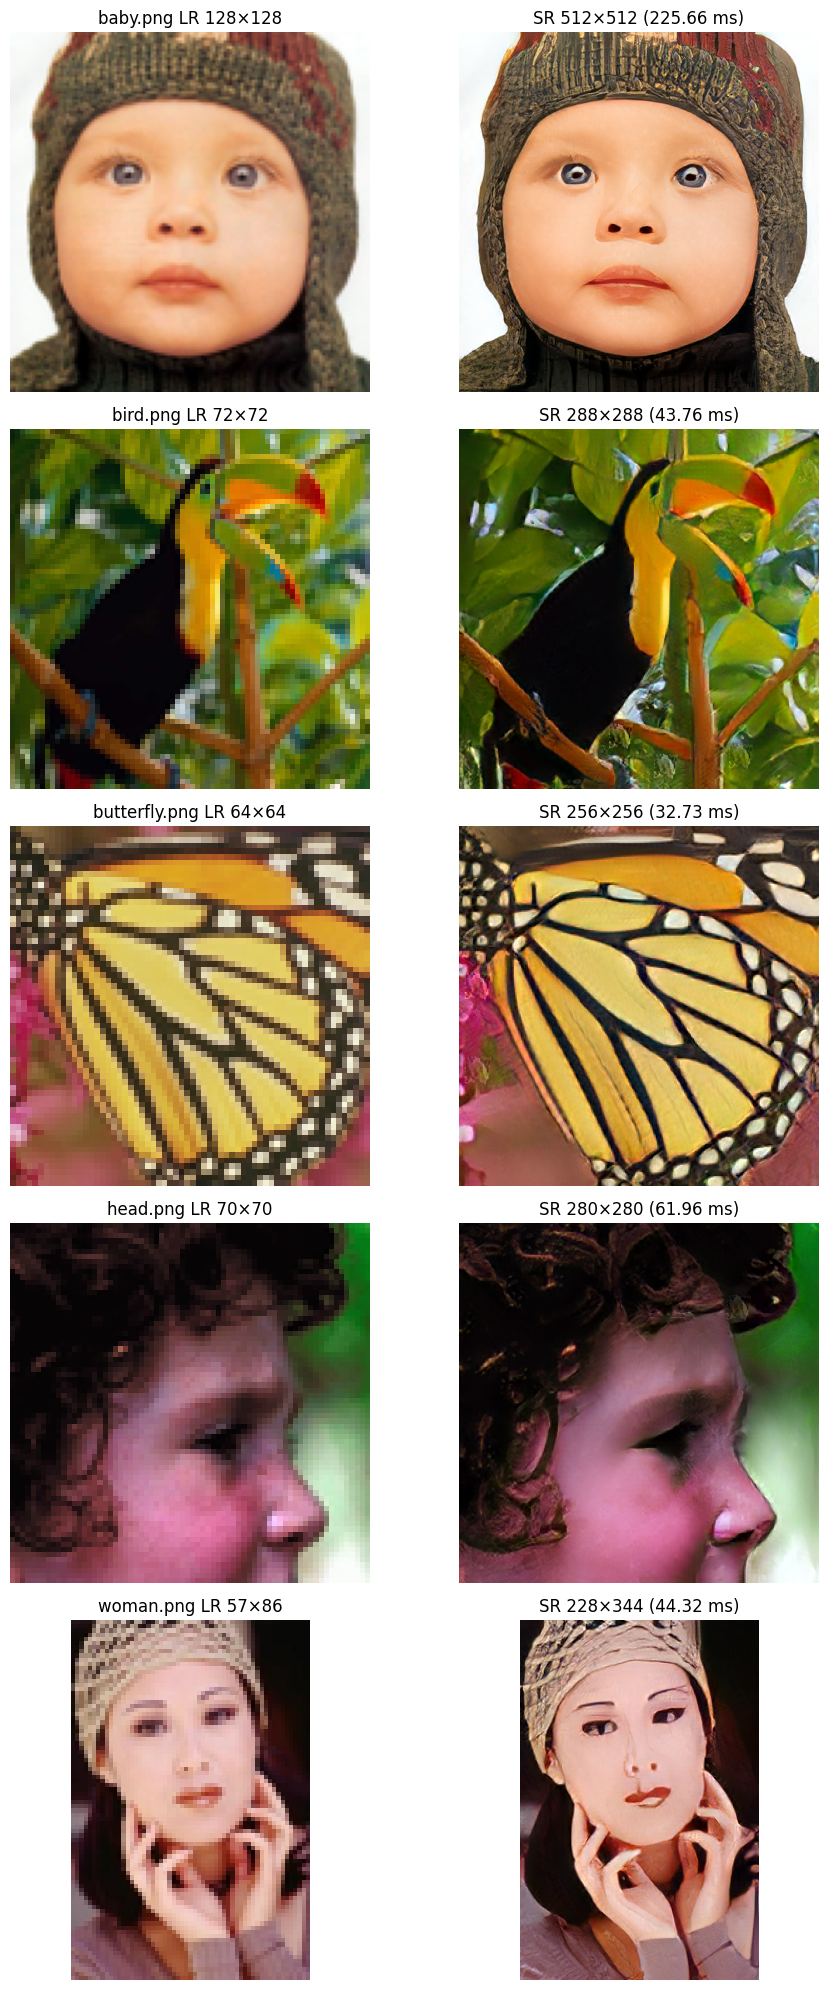

Saved 5 images to: /data1/yinjian/ntire2026-mobile-realworld-sr-vipsl19/tmp/notebook_demo/set5_sr_x4


In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(len(results), 2, figsize=(10, 4 * len(results)))
for row, (name, item) in enumerate(results.items()):
    output_path = OUTPUT_DIR / name
    if not cv2.imwrite(str(output_path), item['sr']):
        raise RuntimeError(f'保存失败：{output_path}')
    lr_rgb = cv2.cvtColor(item['lr'], cv2.COLOR_BGR2RGB)
    sr_rgb = cv2.cvtColor(item['sr'], cv2.COLOR_BGR2RGB)
    axes[row, 0].imshow(lr_rgb)
    axes[row, 0].set_title(f'{name} LR {lr_rgb.shape[1]}×{lr_rgb.shape[0]}')
    axes[row, 1].imshow(sr_rgb)
    axes[row, 1].set_title(f'SR {sr_rgb.shape[1]}×{sr_rgb.shape[0]} ({item["time_ms"]:.2f} ms)')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()
print(f'Saved {len(results)} images to: {OUTPUT_DIR}')